# 09 · Spatial Buffer Analysis — Greater Bilbao Stations

**Objective:** For each of the 7 monitoring stations, extract land use composition
within 500 m / 1 000 m / 2 000 m buffers using OpenStreetMap data via OSMnx.

**Output:** `station_spatial_features.csv` — 7 rows × ~25 spatial features.

**CRS:** EPSG:25830 (ETRS89 / UTM zone 30N) — official Basque Country projection.

**Run environment:** Local Windows/PowerShell with internet access.  
OSMnx requires access to `overpass-api.de` or a mirror — not available in sandboxes.

---
**Author:** Arman Ghaziaskari Naeini  
**Project:** GeoAI Smart City Air Quality Dashboard — Greater Bilbao

## 0 · Imports & Settings

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import geopandas as gpd
import osmnx as ox
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from shapely.geometry import Point
from pathlib import Path

# --- OSMnx settings ---
# Use a reliable Overpass mirror if the default is slow
# ox.settings.overpass_url = "https://overpass.kumi.systems/api/interpreter"
ox.settings.requests_timeout = 60
ox.settings.log_console = False

# --- Output path ---
OUTPUT_DIR = Path("../data/processed")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# --- CRS ---
CRS_GEO  = "EPSG:4326"    # WGS84 — input coordinates
CRS_UTM  = "EPSG:25830"   # ETRS89 UTM 30N — for metric buffer calculations

print(f"OSMnx {ox.__version__} | GeoPandas {gpd.__version__}")

OSMnx 2.1.0 | GeoPandas 1.1.3


## 1 · Station Definitions

Coordinates verified against the project parquet (air_quality_weather.parquet).

In [2]:
# Station metadata — ground truth from the project parquet
STATIONS = [
    {"station": "ALGORTA_BBIZI2", "town": "Getxo",     "zone": "Coastal",    "lat": 43.362056, "lon": -3.022782},
    {"station": "BARAKALDO",      "town": "Barakaldo",  "zone": "Industrial", "lat": 43.298379, "lon": -2.987133},
    {"station": "BASAURI",        "town": "Basauri",    "zone": "Industrial", "lat": 43.241131, "lon": -2.883761},
    {"station": "ERANDIO",        "town": "Erandio",    "zone": "Urban",      "lat": 43.302653, "lon": -2.977240},
    {"station": "MAZARREDO",      "town": "Bilbao",     "zone": "Urban",      "lat": 43.267506, "lon": -2.935188},
    {"station": "MUSKIZ",         "town": "Muskiz",     "zone": "Refinery",   "lat": 43.320713, "lon": -3.112716},
    {"station": "SANTURCE",       "town": "Santurtzi",  "zone": "Port",       "lat": 43.333012, "lon": -3.042560},
]

df_stations = pd.DataFrame(STATIONS)

# Build GeoDataFrame in WGS84, then reproject to UTM 30N for metric buffers
gdf_stations = gpd.GeoDataFrame(
    df_stations,
    geometry=gpd.points_from_xy(df_stations["lon"], df_stations["lat"]),
    crs=CRS_GEO
).to_crs(CRS_UTM)

print(gdf_stations[["station", "zone", "geometry"]].to_string())

          station        zone                        geometry
0  ALGORTA_BBIZI2     Coastal  POINT (498154.017 4801022.028)
1       BARAKALDO  Industrial  POINT (501043.679 4793950.224)
2         BASAURI  Industrial  POINT (509437.316 4787599.108)
3         ERANDIO       Urban  POINT (501845.999 4794425.041)
4       MAZARREDO       Urban  POINT (505259.744 4790523.618)
5          MUSKIZ    Refinery  POINT (490860.632 4796436.599)
6        SANTURCE        Port  POINT (496549.798 4797797.172)


## 2 · OSMnx Land Use Tags

We query four tag categories:
- **landuse** — industrial, residential, commercial, retail, greenfield, forest, grass, meadow, farmland
- **leisure** — park, nature_reserve, garden
- **natural** — wood, scrub, water
- **highway** — for road density

OSMnx returns polygon/multipolygon geometries; we clip them to each buffer.

In [3]:
# OSM tag groups to fetch
TAGS_LANDUSE = {
    "landuse": [
        "industrial", "commercial", "retail",
        "residential", "construction",
        "forest", "grass", "meadow", "greenfield", "farmland",
        "port",
    ]
}

TAGS_GREEN = {
    "leisure": ["park", "nature_reserve", "garden"],
    "natural": ["wood", "scrub", "water"],
}

# Category groupings for the final indicator columns
INDUSTRIAL_TAGS = {"industrial", "port", "construction"}
RESIDENTIAL_TAGS = {"residential"}
COMMERCIAL_TAGS  = {"commercial", "retail"}
GREEN_TAGS       = {"forest", "grass", "meadow", "greenfield", "farmland",
                    "park", "nature_reserve", "garden", "wood", "scrub"}

BUFFER_RADII = [500, 1000, 2000]  # metres

print("Tag config ready.")

Tag config ready.


## 3 · Helper Functions

In [4]:
def fetch_landuse(lat: float, lon: float, radius: int) -> gpd.GeoDataFrame | None:
    """Fetch OSM landuse + green features within `radius` metres of (lat, lon).
    Returns GeoDataFrame in UTM 30N, or None if OSMnx returns nothing.
    """
    all_tags = {**TAGS_LANDUSE, **TAGS_GREEN}
    try:
        gdf = ox.features_from_point((lat, lon), tags=all_tags, dist=radius)
        if gdf.empty:
            return None
        # Keep only polygon features (exclude nodes/points)
        gdf = gdf[gdf.geometry.geom_type.isin(["Polygon", "MultiPolygon"])].copy()
        return gdf.to_crs(CRS_UTM)
    except Exception as e:
        print(f"  ⚠️  OSMnx error: {e}")
        return None


def fetch_roads(lat: float, lon: float, radius: int) -> gpd.GeoDataFrame | None:
    """Fetch road network within radius and return as GeoDataFrame (UTM 30N)."""
    try:
        G = ox.graph_from_point((lat, lon), dist=radius, network_type="drive")
        edges = ox.graph_to_gdfs(G, nodes=False)
        return edges.to_crs(CRS_UTM)
    except Exception as e:
        print(f"  ⚠️  Roads error: {e}")
        return None


def area_fraction(landuse_gdf: gpd.GeoDataFrame,
                  buffer_geom,
                  tag_set: set) -> float:
    """Return fraction (0–1) of buffer area covered by features in tag_set.

    Clips OSM polygons to the buffer, unions them (avoid double-counting
    overlapping polygons), and divides by buffer area.
    """
    if landuse_gdf is None or landuse_gdf.empty:
        return np.nan

    # Determine the tag value column: OSMnx may store it under 'landuse',
    # 'leisure', or 'natural' depending on what was queried.
    tag_values = pd.Series(dtype=str)
    for col in ["landuse", "leisure", "natural"]:
        if col in landuse_gdf.columns:
            tag_values = tag_values.combine_first(landuse_gdf[col].astype(str))

    mask = tag_values.isin(tag_set)
    subset = landuse_gdf[mask]

    if subset.empty:
        return 0.0

    # Clip to buffer and union to remove overlaps
    clipped = subset.geometry.intersection(buffer_geom)
    clipped = clipped[~clipped.is_empty]
    if clipped.empty:
        return 0.0

    union_area = clipped.union_all().area  # shapely 2.x union_all()
    return min(union_area / buffer_geom.area, 1.0)  # cap at 1 (OSM can exceed)


def road_density(roads_gdf: gpd.GeoDataFrame, buffer_geom) -> float:
    """Total road length (m) per km² of buffer area."""
    if roads_gdf is None or roads_gdf.empty:
        return np.nan
    clipped = roads_gdf.geometry.intersection(buffer_geom)
    total_length_m = clipped.length.sum()
    area_km2 = buffer_geom.area / 1e6
    return total_length_m / area_km2 if area_km2 > 0 else np.nan


print("Helper functions defined.")

Helper functions defined.


## 4 · Main Loop — Buffer Analysis per Station

**Estimated time:** ~5–7 minutes (7 stations × 3 radii × 2 OSMnx calls each).  
Results are cached per station to allow re-runs without re-fetching.

In [5]:
records = []  # will hold one dict per (station, radius)

for _, row in gdf_stations.iterrows():
    lat, lon = row["lat"], row["lon"]
    station  = row["station"]
    print(f"\n{'='*50}")
    print(f"  {station} ({row['zone']}) — {lat:.4f}, {lon:.4f}")
    print(f"{'='*50}")

    # Fetch OSM data once at the largest radius — clip down to smaller buffers
    # This minimises API calls (1 landuse + 1 road fetch per station total)
    max_r = max(BUFFER_RADII)

    print(f"  Fetching landuse within {max_r}m ...")
    lu_gdf = fetch_landuse(lat, lon, max_r)
    n_lu = len(lu_gdf) if lu_gdf is not None else 0
    print(f"  → {n_lu} landuse polygons")

    print(f"  Fetching road network within {max_r}m ...")
    rd_gdf = fetch_roads(lat, lon, max_r)
    n_rd = len(rd_gdf) if rd_gdf is not None else 0
    print(f"  → {n_rd} road segments")

    # Station point in UTM
    station_point = row.geometry  # already UTM from gdf_stations.to_crs()

    for r in BUFFER_RADII:
        buf = station_point.buffer(r)

        rec = {
            "station":    station,
            "town":       row["town"],
            "zone":       row["zone"],
            "lat":        lat,
            "lon":        lon,
            "buffer_m":   r,
            "buffer_km2": round(buf.area / 1e6, 4),

            # Land use fractions
            f"green_pct_{r}m":       round(area_fraction(lu_gdf, buf, GREEN_TAGS)       * 100, 2),
            f"industrial_pct_{r}m":  round(area_fraction(lu_gdf, buf, INDUSTRIAL_TAGS)  * 100, 2),
            f"residential_pct_{r}m": round(area_fraction(lu_gdf, buf, RESIDENTIAL_TAGS) * 100, 2),
            f"commercial_pct_{r}m":  round(area_fraction(lu_gdf, buf, COMMERCIAL_TAGS)  * 100, 2),

            # Road density
            f"road_density_{r}m":    round(road_density(rd_gdf, buf), 1),
        }
        records.append(rec)
        print(f"    [{r}m] green={rec[f'green_pct_{r}m']}% "
              f"| industrial={rec[f'industrial_pct_{r}m']}% "
              f"| roads={rec[f'road_density_{r}m']} m/km²")

print("\n✅ Buffer analysis complete.")


  ALGORTA_BBIZI2 (Coastal) — 43.3621, -3.0228
  Fetching landuse within 2000m ...
  → 356 landuse polygons
  Fetching road network within 2000m ...
  → 1100 road segments
    [500m] green=5.8% | industrial=0.0% | roads=9690.5 m/km²
    [1000m] green=16.95% | industrial=0.03% | roads=9932.8 m/km²
    [2000m] green=16.55% | industrial=0.7% | roads=7933.3 m/km²

  BARAKALDO (Industrial) — 43.2984, -2.9871
  Fetching landuse within 2000m ...
  → 1466 landuse polygons
  Fetching road network within 2000m ...
  → 3304 road segments
    [500m] green=12.11% | industrial=0.3% | roads=23207.8 m/km²
    [1000m] green=23.82% | industrial=10.05% | roads=21267.0 m/km²
    [2000m] green=26.99% | industrial=18.91% | roads=18901.3 m/km²

  BASAURI (Industrial) — 43.2411, -2.8838
  Fetching landuse within 2000m ...
  → 524 landuse polygons
  Fetching road network within 2000m ...
  → 1827 road segments
    [500m] green=19.52% | industrial=31.78% | roads=18499.0 m/km²
    [1000m] green=25.29% | industri

## 5 · Reshape to Wide Format (one row per station)

In [6]:
df_long = pd.DataFrame(records)

# Pivot to wide: one row per station, all buffer sizes as columns
# Station metadata columns (not metrics) stay fixed
META_COLS  = ["station", "town", "zone", "lat", "lon"]
METRIC_COLS = [c for c in df_long.columns if c not in META_COLS + ["buffer_m", "buffer_km2"]]

# Each metric is already named with _500m / _1000m / _2000m suffix — just deduplicate
df_wide = (
    df_long
    .groupby(META_COLS, as_index=False)
    .first()   # all radii already encoded in column names; first() keeps one row
    # Actually we need ALL metric columns — re-merge
)

# Better approach: merge all radius slices on station key
df_wide = df_long[META_COLS].drop_duplicates().copy()
for r in BUFFER_RADII:
    slice_r = df_long[df_long["buffer_m"] == r][META_COLS + [c for c in df_long.columns if str(r) in c]]
    df_wide = df_wide.merge(slice_r, on=META_COLS, how="left")

print(f"Wide table: {df_wide.shape[0]} stations × {df_wide.shape[1]} columns")
print(df_wide.columns.tolist())

Wide table: 7 stations × 20 columns
['station', 'town', 'zone', 'lat', 'lon', 'green_pct_500m', 'industrial_pct_500m', 'residential_pct_500m', 'commercial_pct_500m', 'road_density_500m', 'green_pct_1000m', 'industrial_pct_1000m', 'residential_pct_1000m', 'commercial_pct_1000m', 'road_density_1000m', 'green_pct_2000m', 'industrial_pct_2000m', 'residential_pct_2000m', 'commercial_pct_2000m', 'road_density_2000m']


## 6 · Save Output

In [7]:
# Save wide CSV
out_path = OUTPUT_DIR / "station_spatial_features.csv"
df_wide.to_csv(out_path, index=False)
print(f"✅ Saved: {out_path}")

# Also save long format (useful for plotting)
df_long.to_csv(OUTPUT_DIR / "station_spatial_features_long.csv", index=False)
print(f"✅ Saved long format")

df_wide

✅ Saved: ..\data\processed\station_spatial_features.csv
✅ Saved long format


,station,town,zone,lat,lon,green_pct_500m,industrial_pct_500m,residential_pct_500m,commercial_pct_500m,road_density_500m,green_pct_1000m,industrial_pct_1000m,residential_pct_1000m,commercial_pct_1000m,road_density_1000m,green_pct_2000m,industrial_pct_2000m,residential_pct_2000m,commercial_pct_2000m,road_density_2000m
0,ALGORTA_BBIZI2,Getxo,Coastal,43.362056,-3.022782,5.80,0.00,39.07,0.00,9690.5,16.95,0.03,39.11,0.00,9932.8,16.55,0.70,27.25,0.03,7933.3
1,BARAKALDO,Barakaldo,Industrial,43.298379,-2.987133,12.11,0.30,0.00,0.00,23207.8,23.82,10.05,0.41,0.00,21267.0,26.99,18.91,2.74,3.40,18901.3
2,BASAURI,Basauri,Industrial,43.241131,-2.883761,19.52,31.78,0.00,0.06,18499.0,25.29,20.95,7.67,2.65,15953.8,46.15,14.77,7.94,1.12,12969.4
3,ERANDIO,Erandio,Urban,43.302653,-2.977240,8.85,11.00,0.27,0.87,18939.6,25.72,11.63,7.55,0.22,18630.8,31.71,15.25,4.68,0.18,16799.8
4,MAZARREDO,Bilbao,Urban,43.267506,-2.935188,22.06,1.07,92.09,0.00,21347.1,23.82,1.69,77.14,0.00,19059.6,34.34,1.52,66.42,0.00,17479.9
5,MUSKIZ,Muskiz,Refinery,43.320713,-3.112716,27.10,16.72,48.17,0.00,17451.4,26.66,34.58,29.59,0.00,10634.7,41.88,17.08,19.16,0.10,8442.4
6,SANTURCE,Santurtzi,Port,43.333012,-3.042560,41.23,15.28,6.01,0.00,21317.2,31.62,25.59,7.04,0.00,13279.6,33.29,20.48,2.85,0.06,8075.5


## 7 · Visualisation — Land Use Composition per Station

Grouped bar chart: green / industrial / residential / commercial at 1000m buffer.

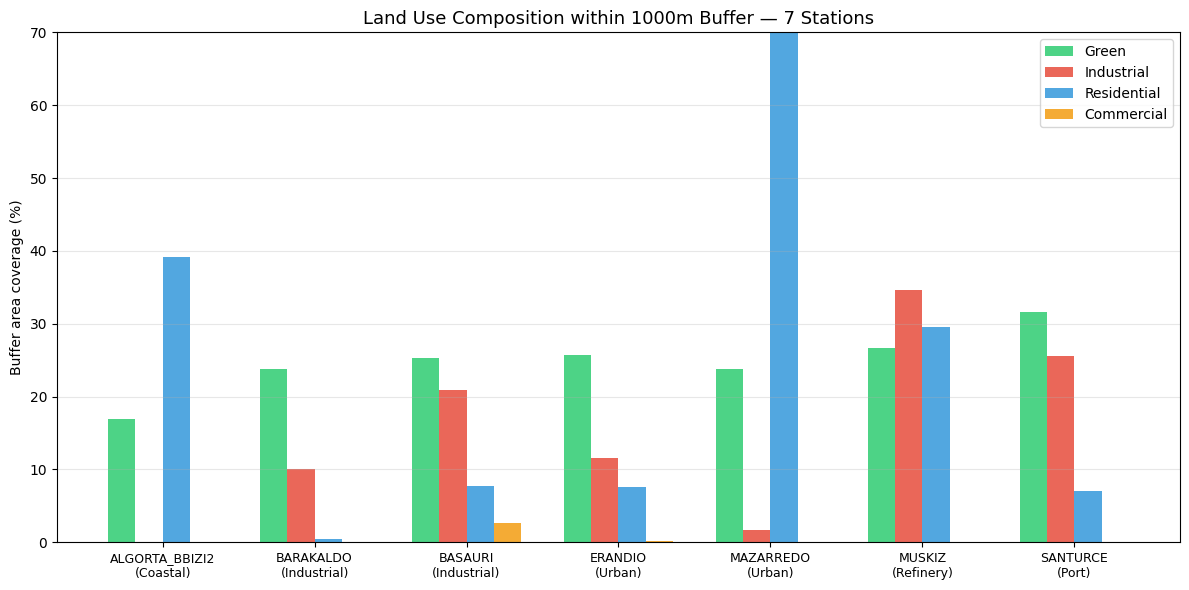

✅ Chart saved.


In [8]:
# --- Stacked bar: land use composition at 1000m ---
RADIUS_PLOT = 1000

categories = ["green", "industrial", "residential", "commercial"]
colors = ["#2ecc71", "#e74c3c", "#3498db", "#f39c12"]

fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(len(df_wide))
width = 0.18
offsets = [-1.5, -0.5, 0.5, 1.5]

for cat, color, offset in zip(categories, colors, offsets):
    col = f"{cat}_pct_{RADIUS_PLOT}m"
    vals = df_wide[col].fillna(0)
    ax.bar(x + offset * width, vals, width, label=cat.capitalize(), color=color, alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(
    [f"{row['station']}\n({row['zone']})" for _, row in df_wide.iterrows()],
    fontsize=9
)
ax.set_ylabel("Buffer area coverage (%)")
ax.set_title(f"Land Use Composition within {RADIUS_PLOT}m Buffer — 7 Stations", fontsize=13)
ax.legend(loc="upper right")
ax.set_ylim(0, 70)
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "buffer_landuse_chart.png", dpi=150)
plt.show()
print("✅ Chart saved.")

## 8 · Visualisation — Road Density Comparison

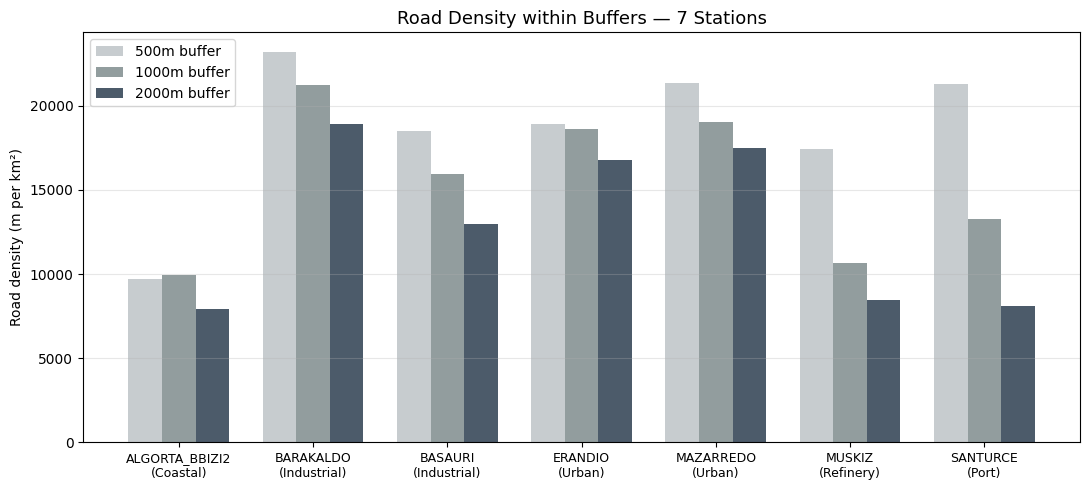

✅ Chart saved.


In [9]:
fig, ax = plt.subplots(figsize=(11, 5))

colors_r = ["#bdc3c7", "#7f8c8d", "#2c3e50"]
for r, color in zip(BUFFER_RADII, colors_r):
    col = f"road_density_{r}m"
    offset_map = {500: -0.25, 1000: 0, 2000: 0.25}
    ax.bar(
        np.arange(len(df_wide)) + offset_map[r],
        df_wide[col].fillna(0),
        width=0.25,
        label=f"{r}m buffer",
        color=color,
        alpha=0.85
    )

ax.set_xticks(np.arange(len(df_wide)))
ax.set_xticklabels(
    [f"{row['station']}\n({row['zone']})" for _, row in df_wide.iterrows()],
    fontsize=9
)
ax.set_ylabel("Road density (m per km²)")
ax.set_title("Road Density within Buffers — 7 Stations", fontsize=13)
ax.legend()
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "buffer_road_density_chart.png", dpi=150)
plt.show()
print("✅ Chart saved.")

## 9 · Correlation: Spatial Features vs Mean Pollutant Levels

Links buffer analysis results to observed air quality.  
Expected: industrial% ↑ → PM2.5/PM10 ↑ | green% ↑ → NO2 ↓ | road_density ↑ → NO2 ↑

In [10]:
# Load air quality data and compute per-station mean pollutants
AQ_PATH = Path("../data/processed/air_quality_weather.parquet")

df_aq = pd.read_parquet(AQ_PATH)[["station", "PM2.5", "PM10", "NO2", "SO2"]]
df_means = df_aq.groupby("station")[["PM2.5", "PM10", "NO2", "SO2"]].mean().reset_index()
df_means.columns = ["station", "mean_PM25", "mean_PM10", "mean_NO2", "mean_SO2"]

# Merge with spatial features (1000m buffer)
df_corr = df_wide.merge(df_means, on="station", how="left")

# Compute correlation matrix
spatial_cols = [c for c in df_wide.columns if "1000m" in c]
pollutant_cols = ["mean_PM25", "mean_PM10", "mean_NO2", "mean_SO2"]

corr_matrix = df_corr[spatial_cols + pollutant_cols].corr().loc[spatial_cols, pollutant_cols]

print("Correlation matrix (spatial features × pollutants):")
print(corr_matrix.round(3).to_string())

Correlation matrix (spatial features × pollutants):
                       mean_PM25  mean_PM10  mean_NO2  mean_SO2
green_pct_1000m           -0.138     -0.657     0.172    -0.106
industrial_pct_1000m      -0.423     -0.734    -0.421    -0.431
residential_pct_1000m     -0.327     -0.111     0.040     0.571
commercial_pct_1000m       0.399      0.371     0.298    -0.707
road_density_1000m         0.678      0.389     0.833     0.386


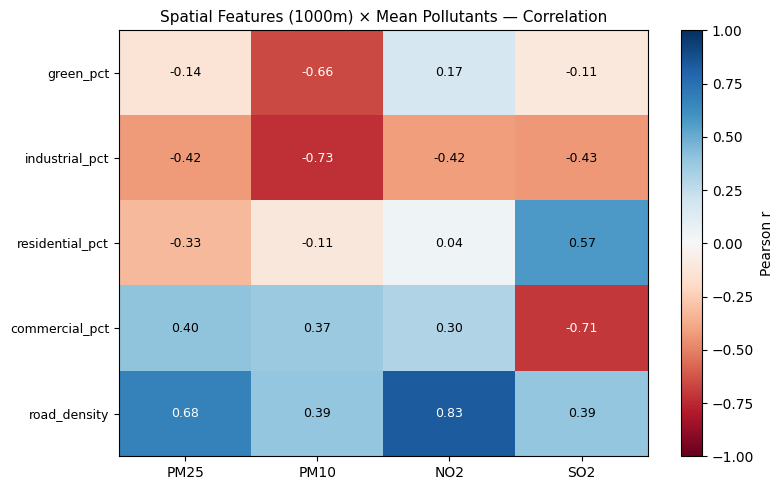

✅ Heatmap saved.


In [11]:
import matplotlib.colors as mcolors

fig, ax = plt.subplots(figsize=(8, 5))

im = ax.imshow(corr_matrix.values, cmap="RdBu", vmin=-1, vmax=1, aspect="auto")

ax.set_xticks(range(len(pollutant_cols)))
ax.set_xticklabels([c.replace("mean_", "") for c in pollutant_cols])
ax.set_yticks(range(len(spatial_cols)))
ax.set_yticklabels([c.replace("_1000m", "") for c in spatial_cols], fontsize=9)

# Annotate cells
for i in range(len(spatial_cols)):
    for j in range(len(pollutant_cols)):
        val = corr_matrix.values[i, j]
        ax.text(j, i, f"{val:.2f}", ha="center", va="center",
                fontsize=9, color="black" if abs(val) < 0.6 else "white")

plt.colorbar(im, ax=ax, label="Pearson r")
ax.set_title("Spatial Features (1000m) × Mean Pollutants — Correlation", fontsize=11)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "spatial_pollutant_correlation.png", dpi=150)
plt.show()
print("✅ Heatmap saved.")

## 10 · Summary Table — Portfolio-Ready

Print a clean table suitable for README / presentation.

In [12]:
# Clean summary at 1000m
summary_cols = {
    "station":             "Station",
    "zone":                "Zone",
    "green_pct_1000m":     "Green %",
    "industrial_pct_1000m":"Industrial %",
    "residential_pct_1000m":"Residential %",
    "road_density_1000m":  "Road density\n(m/km²)",
    "mean_PM25":           "Mean PM2.5",
    "mean_NO2":            "Mean NO2",
}

df_summary = df_corr[list(summary_cols.keys())].copy()
df_summary.columns = summary_cols.values()

df_summary = df_summary.round(2)
print(df_summary.to_string(index=False))

# Save to CSV for README / presentation
df_summary.to_csv(OUTPUT_DIR / "buffer_summary_table.csv", index=False)
print("\n✅ Summary table saved.")

       Station       Zone  Green %  Industrial %  Residential %  Road density\n(m/km²)  Mean PM2.5  Mean NO2
ALGORTA_BBIZI2    Coastal    16.95          0.03          39.11                 9932.8        9.23     12.45
     BARAKALDO Industrial    23.82         10.05           0.41                21267.0       12.40     20.55
       BASAURI Industrial    25.29         20.95           7.67                15953.8       11.41     22.56
       ERANDIO      Urban    25.72         11.63           7.55                18630.8        9.11     23.12
     MAZARREDO      Urban    23.82          1.69          77.14                19059.6        9.73     25.67
        MUSKIZ   Refinery    26.66         34.58          29.59                10634.7        6.51      8.65
      SANTURCE       Port    31.62         25.59           7.04                13279.6        9.39     18.70

✅ Summary table saved.


## 11 · Next Steps

With `station_spatial_features.csv` ready, the natural next analyses are:

1. **Distance features** (`09b_distance_features.ipynb`):  
   Distance to Port of Bilbao, Petronor refinery, nearest motorway junction.  
   Uses OSMnx `nearest_edges` — same fetch pattern, no new data sources.

2. **Elevation + NDVI per station** (`09c_raster_features.ipynb`):  
   `rasterio` + Copernicus DEM 30m (free download, ~50MB for Bizkaia).  
   Mean elevation & terrain roughness in 2km buffer.

3. **Dashboard integration** — add a new tab in Page 6 (Smart City Decision Support)  
   showing the spatial profile of each station alongside its pollution record.

---
*n = 7 stations. Correlations are indicative, not inferential. Explicitly noted in dashboard.*